In [1]:
import pandas as pd

data = {
    "slow": [1, 1, 0, 0, 0, 1, 0, 0, 1, 0],
    "overheating": [1, 1, 0, 0, 0, 0, 1, 0, 1, 0],
    "loud_fan": [1, 1, 0, 0, 0, 0, 1, 0, 1, 0],
    "battery_drain": [0, 0, 1, 1, 0, 0, 0, 1, 0, 1],
    "frequent_crashes": [0, 1, 0, 0, 1, 1, 0, 0, 1, 0],
    "screen_flickering": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    "wifi_problem": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    "charging_problem": [0, 0, 1, 1, 0, 0, 0, 1, 0, 1],
    "problem": [
        "Overheating",
        "Overheating",
        "Battery Issue",
        "Battery Issue",
        "WiFi Issue",
        "Performance Issue",
        "Overheating",
        "Battery Issue",
        "Performance Issue",
        "Charging Issue"
    ]
}

df = pd.DataFrame(data)

df

,slow,overheating,loud_fan,battery_drain,frequent_crashes,screen_flickering,wifi_problem,charging_problem,problem
0,1,1,1,0,0,0,0,0,Overheating
1,1,1,1,0,1,0,0,0,Overheating
2,0,0,0,1,0,0,0,1,Battery Issue
3,0,0,0,1,0,0,0,1,Battery Issue
4,0,0,0,0,1,0,1,0,WiFi Issue
5,1,0,0,0,1,0,0,0,Performance Issue
6,0,1,1,0,0,0,0,0,Overheating
7,0,0,0,1,0,0,0,1,Battery Issue
8,1,1,1,0,1,0,0,0,Performance Issue
9,0,0,0,1,0,1,0,1,Charging Issue


In [3]:
df.head()
df.shape
df.columns
df.info()
df.isna().sum()
df["problem"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   slow               10 non-null     int64 
 1   overheating        10 non-null     int64 
 2   loud_fan           10 non-null     int64 
 3   battery_drain      10 non-null     int64 
 4   frequent_crashes   10 non-null     int64 
 5   screen_flickering  10 non-null     int64 
 6   wifi_problem       10 non-null     int64 
 7   charging_problem   10 non-null     int64 
 8   problem            10 non-null     object
dtypes: int64(8), object(1)
memory usage: 852.0+ bytes


,count
problem,
Overheating,3
Battery Issue,3
Performance Issue,2
WiFi Issue,1
Charging Issue,1


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X = df.drop("problem", axis=1)
y = df["problem"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape
X_test.shape
y_train.shape
y_test.shape
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
prediction
y_test

,problem
8,Performance Issue
1,Overheating


In [8]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": prediction
})

comparison

,Actual,Prediction
0,Performance Issue,Overheating
1,Overheating,Overheating


In [10]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 0.5


In [11]:
new_laptop = [[1, 1, 1, 0, 0, 0, 0, 0]]
new_prediction = model.predict(new_laptop)

print("Predicted Problem:", new_prediction[0])

Predicted Problem: Overheating


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [12]:
import random

data = []

for i in range(150):
    slow = random.randint(0, 1)
    overheating = random.randint(0, 1)
    loud_fan = random.randint(0, 1)
    battery_drain = random.randint(0, 1)
    frequent_crashes = random.randint(0, 1)
    screen_flickering = random.randint(0, 1)
    wifi_problem = random.randint(0, 1)
    charging_problem = random.randint(0, 1)

    if overheating == 1 and loud_fan == 1:
        problem = "Overheating"
    elif battery_drain == 1 and charging_problem == 1:
        problem = "Battery Issue"
    elif screen_flickering == 1:
        problem = "Display Issue"
    elif wifi_problem == 1:
        problem = "WiFi Issue"
    elif slow == 1 and frequent_crashes == 1:
        problem = "Performance Issue"
    elif charging_problem == 1:
        problem = "Charging Issue"
    else:
        problem = "Performance Issue"

    data.append([
        slow, overheating, loud_fan, battery_drain,
        frequent_crashes, screen_flickering,
        wifi_problem, charging_problem, problem
    ])

df = pd.DataFrame(data, columns=[
    "slow",
    "overheating",
    "loud_fan",
    "battery_drain",
    "frequent_crashes",
    "screen_flickering",
    "wifi_problem",
    "charging_problem",
    "problem"
])

df.head()

,slow,overheating,loud_fan,battery_drain,frequent_crashes,screen_flickering,wifi_problem,charging_problem,problem
0,1,1,0,1,1,1,1,0,Display Issue
1,0,1,0,0,1,1,0,1,Display Issue
2,0,1,0,1,1,0,1,0,WiFi Issue
3,0,1,1,0,0,0,1,0,Overheating
4,0,1,1,1,0,0,1,1,Overheating


In [13]:
X = df.drop("problem", axis=1)
y = df["problem"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 0.8666666666666667


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, prediction)

print(cm)

[[ 2  0  1  0  0  0]
 [ 0  1  0  0  0  0]
 [ 0  1 12  0  0  0]
 [ 0  0  0  8  0  0]
 [ 0  0  0  1  0  0]
 [ 0  0  1  0  0  3]]


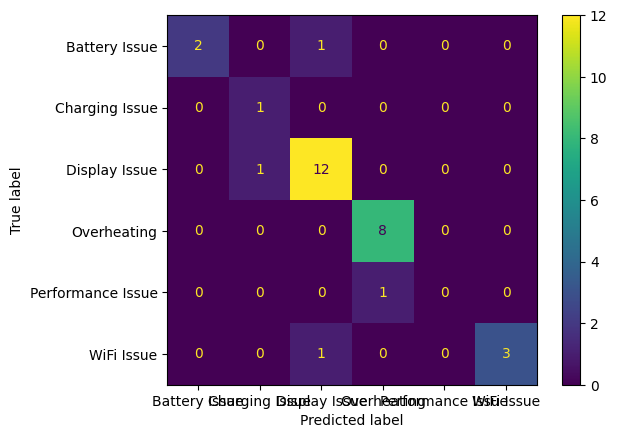

In [17]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.show()

In [18]:
from sklearn.metrics import classification_report

report = classification_report(y_test, prediction)
print(report)

                   precision    recall  f1-score   support

    Battery Issue       1.00      0.67      0.80         3
   Charging Issue       0.50      1.00      0.67         1
    Display Issue       0.86      0.92      0.89        13
      Overheating       0.89      1.00      0.94         8
Performance Issue       0.00      0.00      0.00         1
       WiFi Issue       1.00      0.75      0.86         4

         accuracy                           0.87        30
        macro avg       0.71      0.72      0.69        30
     weighted avg       0.86      0.87      0.85        30



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
new_laptop = [[1, 1, 1, 0, 0, 0, 0, 0]]

new_prediction = model.predict(new_laptop)

print("Predicted Problem:", new_prediction[0])

Predicted Problem: Overheating


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [20]:
new_laptop = pd.DataFrame([{
    "slow": 1,
    "overheating": 1,
    "loud_fan": 1,
    "battery_drain": 0,
    "frequent_crashes": 0,
    "screen_flickering": 0,
    "wifi_problem": 0,
    "charging_problem": 0
}])

new_prediction = model.predict(new_laptop)

print("Predicted Problem:", new_prediction[0])

Predicted Problem: Overheating


In [22]:
!pip install gradio
import gradio as gr

def predict_problem(
    slow,
    overheating,
    loud_fan,
    battery_drain,
    frequent_crashes,
    screen_flickering,
    wifi_problem,
    charging_problem
):
    new_laptop = pd.DataFrame([{
        "slow": int(slow),
        "overheating": int(overheating),
        "loud_fan": int(loud_fan),
        "battery_drain": int(battery_drain),
        "frequent_crashes": int(frequent_crashes),
        "screen_flickering": int(screen_flickering),
        "wifi_problem": int(wifi_problem),
        "charging_problem": int(charging_problem)
    }])

    prediction = model.predict(new_laptop)

    return prediction[0]


demo = gr.Interface(
    fn=predict_problem,
    inputs=[
        gr.Checkbox(label="Laptop is slow"),
        gr.Checkbox(label="Laptop is overheating"),
        gr.Checkbox(label="Fan is loud"),
        gr.Checkbox(label="Battery drains quickly"),
        gr.Checkbox(label="Laptop crashes frequently"),
        gr.Checkbox(label="Screen is flickering"),
        gr.Checkbox(label="WiFi problem"),
        gr.Checkbox(label="Charging problem")
    ],
    outputs=gr.Textbox(label="Predicted Problem"),
    title="Laptop Problem Matcher",
    description="Select the symptoms of your laptop to predict the most likely problem."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c2ed9bd9ff7c704c2d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
